In [2]:
import os
import shutil
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [8]:
ORIGINAL_DATA_DIR = 'data/brain_tumor_data'
SPLIT_DATA_DIR = 'data_split/brain_tumor_data'

TRAIN_DIR = os.path.join(SPLIT_DATA_DIR, 'train')
VAL_DIR = os.path.join(SPLIT_DATA_DIR, 'val')
TEST_DIR = os.path.join(SPLIT_DATA_DIR, 'test')

In [18]:
def create_dataset_splits(source_dir, train_dir, val_dir, test_dir, split_ratio=(0.7, 0.15, 0.15)):
    if not os.path.exists(source_dir):
        print(f"Error: Could not find the source folder: {source_dir}")
        return
    classes = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    print(f"Discovered {len(classes)} classes of tumors.\nSplitting dataset into {split_ratio} (Train, Val, Test)...\n")
    for class_name in classes:
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        class_folder_path = os.path.join(source_dir, class_name)
        images = os.listdir(class_folder_path)
        random.shuffle(images)

        total_images = len(images)
        train_cut = int(total_images * split_ratio[0])
        val_cut = int(total_images * split_ratio[1])

        train_images = images[:train_cut]
        val_images = images[train_cut:val_cut]
        test_images = images[val_cut:]

    for img in train_images:
        shutil.copy(os.path.join(class_folder_path, img), os.path.join(train_dir, class_name, img))
    for img in val_images:
        shutil.copy(os.path.join(class_folder_path, img), os.path.join(train_dir, class_name, img))
    for img in test_images:
        shutil.copy(os.path.join(class_folder_path, img), os.path.join(train_dir, class_name, img))
    
    print("Success! Images have been split into the robust 'data_split/' directory.")

create_dataset_splits(ORIGINAL_DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

Discovered 4 classes of tumors.
Splitting dataset into (0.7, 0.15, 0.15) (Train, Val, Test)...

Success! Images have been split into the robust 'data_split/' directory.


In [20]:
def count_images(split_data_dir):
    for main_split in ['train', 'val', 'test']:
        split_path = os.path.join(split_data_dir, main_split)
        if not os.path.exists(split_path):
            os.makedirs(split_path)
            continue
        print(f"\n--- Output for {main_split.upper()} set ---")
        for disease_folder in os.listdir(split_path):
            disease_path = os.path.join(split_path, disease_folder)
            if os.path.isdir(disease_path):
                image_count = len(os.listdir(disease_path))
                print(f"  > {disease_folder}: {image_count} images")
count_images(SPLIT_DATA_DIR)


--- Output for TRAIN set ---
  > glioma: 1260 images
  > pituitary: 1260 images
  > meningioma: 1260 images
  > notumor: 1260 images

--- Output for VAL set ---
  > glioma: 270 images
  > pituitary: 270 images
  > meningioma: 270 images
  > notumor: 270 images

--- Output for TEST set ---
  > glioma: 270 images
  > pituitary: 270 images
  > meningioma: 270 images
  > notumor: 270 images


In [21]:
IMG_SIZE = (224, 224)
# We **do NOT** augment the Validation or Test Sets. We want to test the model on normal, un-altered images.
# BATCH SIZE: How many images the AI processes at once before updating its "memory".
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range = 15,
    width_shift_range=0.1,        
    height_shift_range=0.1,      
    brightness_range=[0.9, 1.1], 
    horizontal_flip=True     
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [22]:
# LOADING THE IMAGES FROM FOLDERS INTO MEMORY

# Connect the Train Generator to the 'train' folder
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())

Found 5040 images belonging to 4 classes.
Found 1080 images belonging to 4 classes.
Found 5040 images belonging to 4 classes.


In [23]:
from tensorflow.keras.layers import Dropout
base_model = DenseNet121(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

predictions = Dense(NUM_CLASSES, activation = 'softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

2026-03-04 21:23:24.117773: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
EPOCHS = 15
os.makedirs('../inference/models', exist_ok=True)
MODEL_SAVE_PATH = '../inference/models/brain_tumor_densenet121.keras'

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor='val_loss',
    save_best_only=True,
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr, model_checkpoint]
)

print(f"\n✅ Training concluded! The best version was safely deposited at {MODEL_SAVE_PATH}")

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.3827 - loss: 1.4676 - val_accuracy: 0.5778 - val_loss: 1.0595 - learning_rate: 1.0000e-04
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 404s 3s/step - accuracy: 0.5024 - loss: 1.1854 - val_accuracy: 0.6537 - val_loss: 0.8844 - learning_rate: 1.0000e-04
Epoch 3/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - accuracy: 0.5778 - loss: 1.0136 - val_accuracy: 0.7093 - val_loss: 0.7832 - learning_rate: 1.0000e-04
Epoch 4/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - accuracy: 0.6153 - loss: 0.9212 - val_accuracy: 0.7444 - val_loss: 0.7054 - learning_rate: 1.0000e-04
Epoch 5/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.6587 - loss: 0.8423 - val_accuracy: 0.7630 - val_loss: 0.6630 - learning_rate: 1.0000e-04
Epoch 6/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.6867 - loss: 0.7823 - val_accuracy: 0.7852 - val_loss: 0.6161 - learning_rate: 1.0000e-04
Epoch 7/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 376s 2s/step - acc

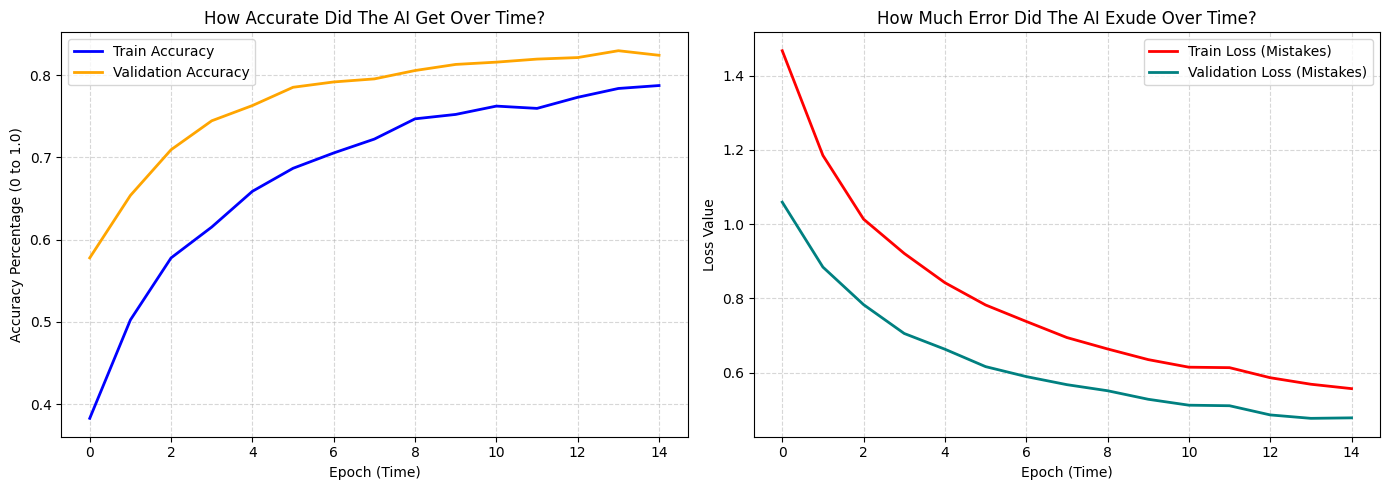

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy', linewidth=2, color='blue')
plt.plot(val_acc, label='Validation Accuracy', linewidth=2, color='orange')
plt.title('How Accurate Did The AI Get Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Accuracy Percentage (0 to 1.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss (Mistakes)', linewidth=2, color='red')
plt.plot(val_loss, label='Validation Loss (Mistakes)', linewidth=2, color='teal')
plt.title('How Much Error Did The AI Exude Over Time?')
plt.xlabel('Epoch (Time)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [29]:
test_loss, test_acc = model.evaluate(test_generator)

print(f"🎯 Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"📉 Final Test Loss/Error: {test_loss:.4f}")

158/158 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.8421 - loss: 0.4608
🎯 Final Test Accuracy: 84.21%
📉 Final Test Loss/Error: 0.4608


158/158 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step
----------- PREDICTION TEXT REPORT -----------
              precision    recall  f1-score   support

      glioma       0.90      0.77      0.83      1260
  meningioma       0.76      0.70      0.72      1260
     notumor       0.91      0.94      0.93      1260
   pituitary       0.81      0.97      0.88      1260

    accuracy                           0.84      5040
   macro avg       0.84      0.84      0.84      5040
weighted avg       0.84      0.84      0.84      5040



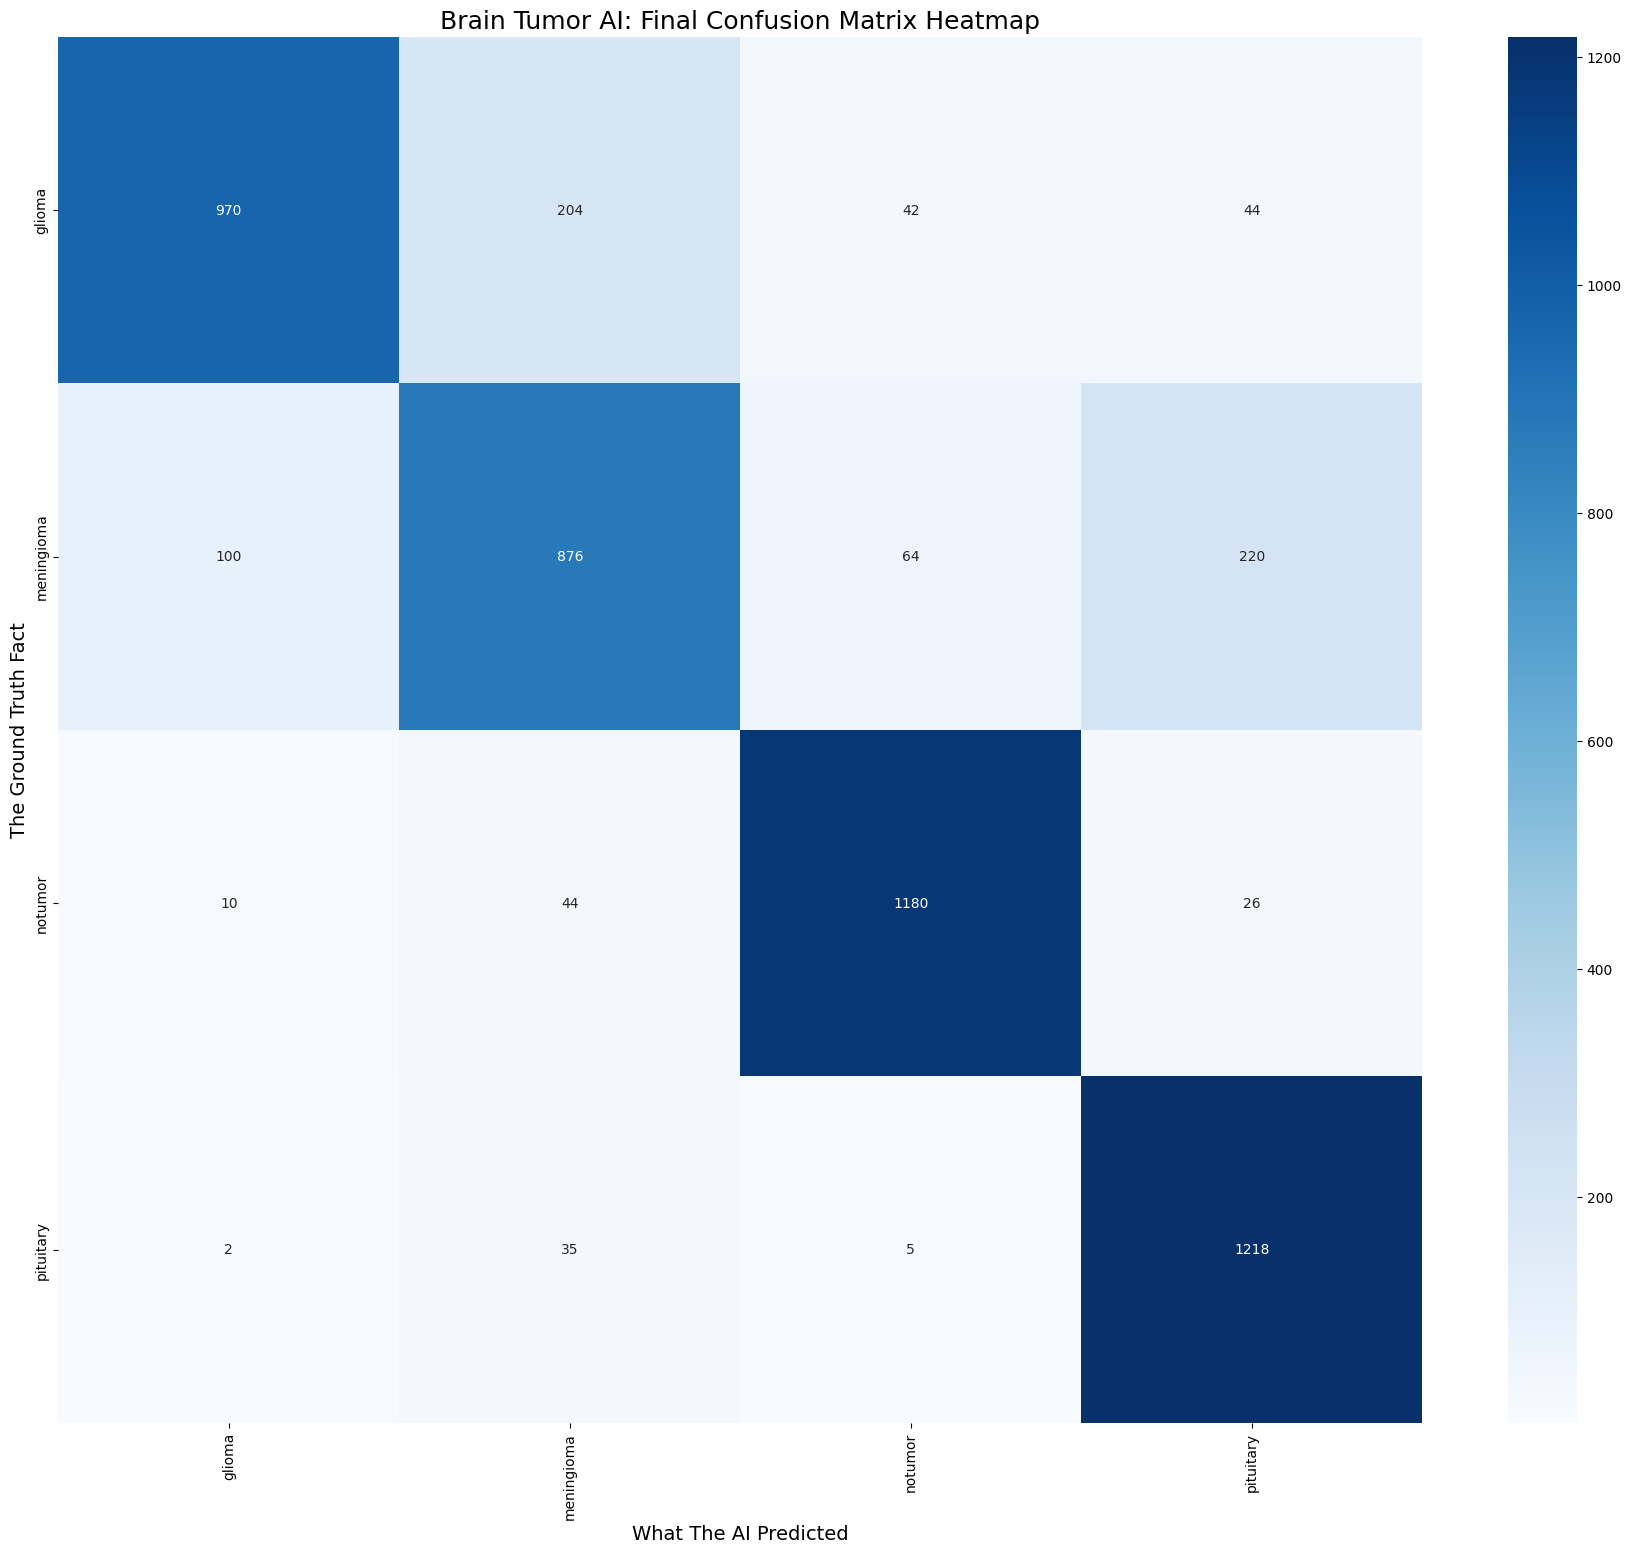

In [30]:
test_generator.reset()

predictions_prob = model.predict(test_generator)

predicted_classes = np.argmax(predictions_prob, axis=1)

true_classes = test_generator.classes

# --- PRINT TEXTUAL REPORT ---
print("----------- PREDICTION TEXT REPORT -----------")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# --- DRAW CONFUSION MATRIX GRAPH ---
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(22, 18))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

plt.title('Brain Tumor AI: Final Confusion Matrix Heatmap', fontsize=18)
plt.xlabel('What The AI Predicted', fontsize=14)
plt.ylabel('The Ground Truth Fact', fontsize=14)
plt.xticks(rotation=90)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0822659].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.169412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2914162].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.605

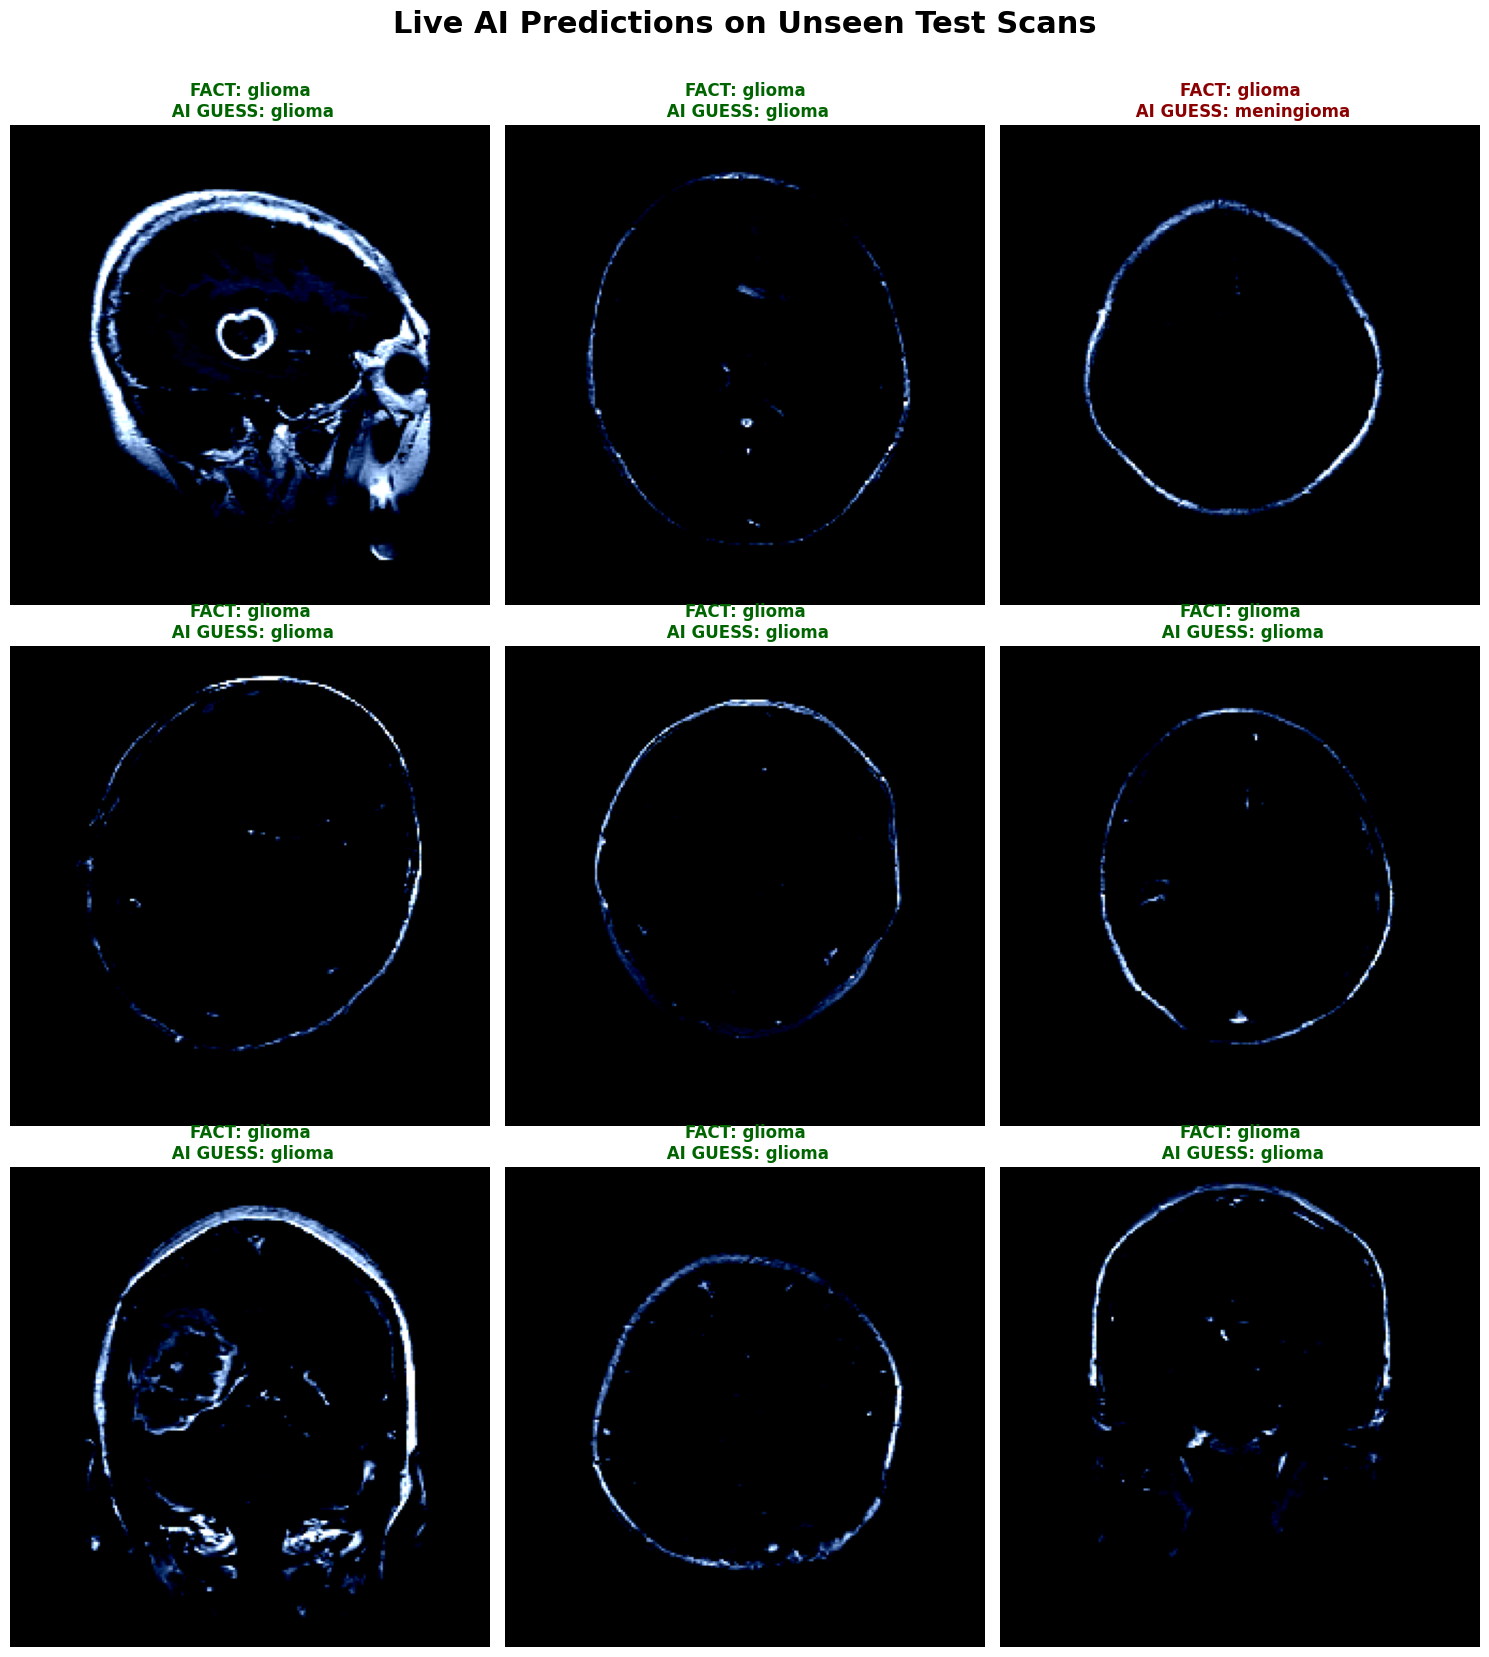

In [31]:
test_generator.reset()
images, onehot_labels = next(test_generator)

preds = model.predict(images)

pred_ids = np.argmax(preds, axis=1)
true_ids = np.argmax(onehot_labels, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(15, 17))
axes = axes.ravel()

for i in range(9):
    if i < len(images):
        axes[i].imshow(images[i])
        
        true_name = class_names[true_ids[i]]
        pred_name = class_names[pred_ids[i]]

        text_color = "darkgreen" if true_ids[i] == pred_ids[i] else "darkred"
        
        axes[i].set_title(f"FACT: {true_name}\n AI GUESS: {pred_name}", color=text_color, fontweight="bold", fontsize=12)
        axes[i].axis('off') # Hide graph axes borders

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle('Live AI Predictions on Unseen Test Scans', fontsize=22, fontweight='bold')
plt.show()

In [32]:

confidence = np.max(predictions_prob, axis=1)

high_conf_count = np.sum(confidence >= 0.95)
total = len(confidence)
print(f"Predictions with ≥95% confidence: {high_conf_count}/{total} ({high_conf_count/total*100:.2f}%)")

Predictions with ≥95% confidence: 1046/5040 (20.75%)
